In [2]:
import ast
import glob
import warnings
from collections import defaultdict
from datetime import date

import numpy as np
import pandas as pd
import wandb
import os

In [37]:
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.ticker import MaxNLocator

In [31]:
# --- . Impostazioni Stile Professionale ---
# Usa lo stile 'whitegrid' per una griglia leggera di sfondo
sns.set_theme(style="whitegrid", context="paper", font_scale=1.4)
# Imposta font serif (stile LaTeX)
plt.rcParams['font.family'] = 'serif'
# Rimuovi i bordi superiore e destro per pulizia
plt.rcParams['axes.spines.top'] = False
plt.rcParams['axes.spines.right'] = False

In [4]:
pd.set_option('display.max_rows', 500)
pd.set_option('display.max_columns', 500)

In [5]:
def normalize_column(df, column_to_normalize):
    # Use json_normalize to flatten the nested dictionaries into separate columns
    flattened_df = pd.json_normalize(df[column_to_normalize])
    # Rename columns to include 'nested_column' prefix
    flattened_df.columns = [
        f"{column_to_normalize}.{col}" for col in flattened_df.columns
    ]
    # Concatenate the flattened DataFrame with the original DataFrame
    result_df = pd.concat([df, flattened_df], axis=1)
    # Get new columns names
    new_columns = flattened_df.columns
    # Drop the original nested column if needed
    result_df.drop(column_to_normalize, axis=1, inplace=True)
    return result_df, new_columns

In [6]:
metrics_classification = [ "test/accuracy", "test/auroc", "test/precision", "test/recall" ]
metrics_regression = ["test/mse", "test/mae"]

In [7]:
today = date.today()
api = wandb.Api()

In [8]:
def download_experiments(
    user,
    experiments,
    results = pd.DataFrame()
    ):
    for project_name in experiments:
        # # Find all csv files in the current directory
        csv_files = glob.glob(f"{user}/*.csv")
        # # Collect all the names of the csv files without the extension
        csv_names = []

        for csv_file in csv_files:
            filename = csv_file.split('\\')[-1]
            no_ext = filename[:-4]
            csv_names.append(no_ext)

        if project_name not in csv_names:
            print(f"Downloading {project_name} from Weights & Biases...")
            runs = api.runs(f"{user}/{project_name}")

            summary_list, config_list, name_list = [], [], []
            for run in runs:
                # .summary contains the output keys/values for metrics like accuracy.
                #  We call ._json_dict to omit large files
                summary_list.append(run.summary._json_dict)

                # .config contains the hyperparameters.
                #  We remove special values that start with _.
                config_list.append(
                    {k: v for k, v in run.config.items() if not k.startswith("_")}
                )

                # .name is the human-readable name of the run.
                name_list.append(run.name)

            runs_df = pd.DataFrame(
                {"summary": summary_list, "config": config_list, "name": name_list}
            )

            # making sure folder exists
            if not os.path.exists(user):
                os.makedirs(user)

            runs_df.to_csv(
                os.path.join(
                    user,
                    f"{project_name}.csv")
            )
        else:
            print(f"Loading {project_name}...")
            runs_df = pd.read_csv(
                os.path.join(
                    user,
                    f"{project_name}.csv"
                ), index_col=0)

            for row in runs_df.iloc:
                row["summary"] = ast.literal_eval(row["summary"])
                row["config"] = ast.literal_eval(row["config"])


        for row in runs_df.iloc:
            row["summary"].update(row["config"])

        lst = [i["summary"] for i in runs_df.iloc]
        df = pd.DataFrame.from_dict(lst)

        # Config columns to normalize
        columns_to_normalize = ["model", "dataset", "callbacks", "paths"]

        # Keep track of config columns added
        config_columns = []
        for column in columns_to_normalize:
            df, columns = normalize_column(df, column)
            config_columns.extend(columns)

        # Fill NaN values in config columns with a default value
        if 'model.backbone_wrapper.sampler.sampler_name' in df.columns:
            df['model.backbone_wrapper.sampler.sampler_name'] = df['model.backbone_wrapper.sampler.sampler_name'].fillna("FullGraph")
        else:
            df['model.backbone_wrapper.sampler.sampler_name'] = "FullGraph"

        #just in case
        df["wb_experiment"] = project_name

        # for US-county-demos datasets
        try:
            df['dataset.loader.parameters.data_name'] = np.where(df['dataset.loader.parameters.task_variable'].notna(), df['dataset.loader.parameters.task_variable'], df['dataset.loader.parameters.data_name'])
        except:
            print("No task")

        try:
            results["model.backbone._target_"] = np.where( 
                results["model.backbone._target_"].isna(), 
                results["model.model_name"],  
                results["model.backbone._target_"])
        except:
            print("No target_ column in results")

        # some expeirements are regression only
        if metrics_classification[0] in df.columns and metrics_classification[1] in df.columns:
            df[ metrics_classification] = df[ metrics_classification] * 100

        return pd.concat( [results, df ], ignore_index=True, axis=0)

In [9]:
def mean_pm_std(x):
    return f"{np.mean(x):.2f} ± {np.std(x):.2f}"

In [10]:
latex_params = {
    "index":False,
    "escape":False,           # allow LaTeX in column names like \%
    "na_rep":"–",
    "float_format":"%.3f",    # control decimals
    #column_format="l" + "r" * (df.shape[1]-1),  # left then right-aligned cols
    "bold_rows":False
}

In [11]:
projects = [
    "graph_tabpfn"
    ]

In [12]:
results = download_experiments(
    user="cino-sapienza-universit-di-roma",
    experiments=projects
    )           

Loading graph_tabpfn...
No task
No target_ column in results


In [13]:
lev_experiments = [
    "graph_tabpfn"
]

In [14]:
results = download_experiments(
    user="levsap",
    experiments=lev_experiments,
    results=results
    )           

Loading graph_tabpfn...


In [15]:
[column for column in results.columns if "test" in column]

['test/accuracy',
 'test/auroc',
 'test/average_precision',
 'test/cohen_kappa',
 'test/f1_score',
 'test/jaccard',
 'test/loss',
 'test/mcc',
 'test/precision',
 'test/recall',
 'test',
 'model.backbone_wrapper.num_test_nodes',
 'test/mae',
 'test/mse',
 'test/r2']

In [16]:
results["model.backbone._target_"].unique()

array(['sklearn.tree.DecisionTreeClassifier',
       'sklearn.ensemble.RandomForestClassifier',
       'sklearn.ensemble.HistGradientBoostingClassifier',
       'lightgbm.LGBMClassifier', 'tabpfn.TabPFNClassifier',
       'sklearn.multiclass.OneVsRestClassifier',
       'sklearn.linear_model.LogisticRegression',
       'sklearn.neural_network.MLPClassifier',
       'torch_geometric.nn.models.GCN', 'torch_geometric.nn.models.GIN',
       'torch_geometric.nn.models.GAT'], dtype=object)

In [17]:
results["Transforms"] = np.where( results['transforms'].notna(), "NFA", "No")

C:\Users\loris\AppData\Local\Temp\ipykernel_35256\3184505337.py:1: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  results["Transforms"] = np.where( results['transforms'].notna(), "NFA", "No")


In [18]:
results['model.backbone._target_'].unique()

array(['sklearn.tree.DecisionTreeClassifier',
       'sklearn.ensemble.RandomForestClassifier',
       'sklearn.ensemble.HistGradientBoostingClassifier',
       'lightgbm.LGBMClassifier', 'tabpfn.TabPFNClassifier',
       'sklearn.multiclass.OneVsRestClassifier',
       'sklearn.linear_model.LogisticRegression',
       'sklearn.neural_network.MLPClassifier',
       'torch_geometric.nn.models.GCN', 'torch_geometric.nn.models.GIN',
       'torch_geometric.nn.models.GAT'], dtype=object)

In [61]:
[ column for column in results.columns if "epoch" in column ]

['epoch',
 'callbacks.early_stopping.check_on_train_epoch_end',
 'callbacks.model_checkpoint.every_n_epochs',
 'callbacks.model_checkpoint.save_on_train_epoch_end',
 'AvgTime/train_epoch_mean',
 'AvgTime/train_epoch_std',
 'AvgTime/val_epoch_mean',
 'AvgTime/val_epoch_std']

In [64]:
results[[
'epoch',
 'callbacks.early_stopping.check_on_train_epoch_end',
 'callbacks.model_checkpoint.every_n_epochs',
 'callbacks.model_checkpoint.save_on_train_epoch_end',
 'AvgTime/train_epoch_mean',
 'AvgTime/train_epoch_std',
 'AvgTime/val_epoch_mean',
 'AvgTime/val_epoch_std'
]]

,epoch,callbacks.early_stopping.check_on_train_epoch_end,callbacks.model_checkpoint.every_n_epochs,callbacks.model_checkpoint.save_on_train_epoch_end,AvgTime/train_epoch_mean,AvgTime/train_epoch_std,AvgTime/val_epoch_mean,AvgTime/val_epoch_std
0,0.0,None,None,None,NaN,NaN,NaN,NaN
1,0.0,None,None,None,NaN,NaN,NaN,NaN
2,0.0,None,None,None,NaN,NaN,NaN,NaN
3,0.0,None,None,None,NaN,NaN,NaN,NaN
4,0.0,None,None,None,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...
1861,483.0,None,None,None,0.037644,0.008254,0.015740,0.005437
1862,394.0,None,None,None,0.038774,0.008338,0.015830,0.005082
1863,483.0,None,None,None,0.037151,0.007923,0.015720,0.004890
1864,425.0,None,None,None,0.038114,0.009029,0.016025,0.005282


In [60]:
results[
    ['_runtime',
 '_timestamp',
 'callbacks.model_timer._target_',
 'callbacks.model_checkpoint.train_time_interval']
]

,_runtime,_timestamp,callbacks.model_timer._target_,callbacks.model_checkpoint.train_time_interval
0,209.000000,1.766014e+09,topobench.callbacks.timer_callback.PipelineTimer,None
1,552.000000,1.766015e+09,topobench.callbacks.timer_callback.PipelineTimer,None
2,486.000000,1.766015e+09,topobench.callbacks.timer_callback.PipelineTimer,None
3,491.000000,1.766015e+09,topobench.callbacks.timer_callback.PipelineTimer,None
4,52.000000,1.766014e+09,topobench.callbacks.timer_callback.PipelineTimer,None
...,...,...,...,...
1861,22.004793,1.761405e+09,topobench.callbacks.timer_callback.PipelineTimer,None
1862,18.491751,1.761405e+09,topobench.callbacks.timer_callback.PipelineTimer,None
1863,21.292626,1.761405e+09,topobench.callbacks.timer_callback.PipelineTimer,None
1864,19.468423,1.761405e+09,topobench.callbacks.timer_callback.PipelineTimer,None


In [19]:
# Renaming model's name
map_name = {
    'sklearn.ensemble.HistGradientBoostingRegressor': 'HGBR',
    'sklearn.neural_network.MLPRegressor': 'MLPR',
    'sklearn.ensemble.RandomForestRegressor' : 'RFR',
    'sklearn.tree.DecisionTreeRegressor' : 'DTR', 
    'lightgbm.LGBMRegressor': 'LGBMR',
    'xgboost.XGBRegressor' : "XGBR", 
    'tabpfn.TabPFNClassifier': "TabPFNC", 
    'sklearn.neural_network.MLPClassifier': "MPLC",
    'sklearn.ensemble.RandomForestClassifier': "RFC",
    'sklearn.ensemble.HistGradientBoostingClassifier': "HGBC",
    'sklearn.tree.DecisionTreeClassifier': "DTC",
    'sklearn.linear_model.LogisticRegression': "LogR",
    'sklearn.linear_model.LinearRegression': "LinR",
    'xgboost.XGBClassifier' : "XGBC", 
    'lightgbm.LGBMClassifier': "LGBMC",
    'sklearn.svm.SVC': 'SVC',
    'tabpfn.TabPFNRegressor': "TabPFNR", 
    'torch_geometric.nn.models.GCN': "GCN", 
    'torch_geometric.nn.models.GIN': "GIN",
    'torch_geometric.nn.models.GAT': "GAT", 
    'sklearn.multiclass.OneVsRestClassifier': "TabPFNC"
}

results['model.backbone._target_'] = results['model.backbone._target_'].map(map_name)

In [20]:
#df_regression = results[results[metrics_regression].notna().all(axis=1)]
#df_regression['dataset.loader.parameters.data_name'].value_counts()

In [21]:
df_classification = results[results[metrics_classification].notna().all(axis=1)]
df_classification['dataset.loader.parameters.data_name'].value_counts()

dataset.loader.parameters.data_name
Cora              380
citeseer          376
roman_empire      231
PubMed             88
minesweeper        85
tolokers           85
amazon_ratings     70
tolokers-2         70
wiki_cs            70
questions          69
artnet-exp         68
city-reviews       51
web-fraud          19
Name: count, dtype: int64

In [22]:
df_classification["model.backbone._target_"].value_counts()

model.backbone._target_
TabPFNC    905
HGBC       125
LGBMC      125
RFC        121
LogR       120
MPLC       120
DTC        116
GAT         10
GCN         10
GIN         10
Name: count, dtype: int64

In [23]:
df_classification["model.backbone_wrapper.sampler.sampler_name"].value_counts()

model.backbone_wrapper.sampler.sampler_name
FullGraph          883
GraphHopSampler    747
KNNSampler          32
Name: count, dtype: int64

In [24]:
# taking needed columns
df_classification = df_classification[[
    "dataset.loader.parameters.data_name",
    "Transforms",
    'model.backbone_wrapper.use_embeddings',
    'model.backbone._target_',
    'test/accuracy',
    'test/precision',
    'test/average_precision',
    'test/cohen_kappa',
    'test/f1_score',
    'test/jaccard',
    'test/mcc',
    'model.backbone_wrapper.sampler.sampler_name',
    'model.backbone_wrapper.sampler.n_hops', 
    'model.backbone_wrapper.sampler.k',
    'model.backbone_wrapper.num_test_nodes'
     ]]

df_classification = df_classification.rename(columns={
    'dataset.loader.parameters.data_name': 'Dataset',
    'model.backbone_wrapper.use_embeddings': 'Embedddings',
    'model.backbone._target_': 'Backbone',
    'test/accuracy': 'Accuracy',
    'test/precision': 'Precision',
    'test/average_precision': "AP",
    'test/cohen_kappa': "K",
    'test/f1_score': "F1",
    'test/jaccard': 'Jaccard',
    'test/mcc': 'MCC',
    'model.backbone_wrapper.sampler.sampler_name': 'Sampler',
    'model.backbone_wrapper.sampler.n_hops': 'n_hops', 
    'model.backbone_wrapper.sampler.k': 'k',
    'model.backbone_wrapper.num_test_nodes': 'NumTestNodes'
})

In [25]:
# df_regression = df_regression[[
#     "dataset.loader.parameters.data_name",
#     "Transforms",
#     'model.backbone_wrapper.use_embeddings',
#     'model.backbone._target_',
#     'test/mse',
#     'test/r2',
#     'model.backbone_wrapper.sampler.sampler_name'
#      ]]

# df_regression = df_regression.rename(columns={
#     'dataset.loader.parameters.data_name': 'Dataset',
#     'model.backbone_wrapper.use_embeddings': 'Embedddings',
#     'model.backbone._target_': 'Backbone',
#     'test/mse': 'MSE',
#     'test/r2': 'R2',
#     'model.backbone_wrapper.sampler.sampler_name': 'Sampler'
# })

In [26]:
df_classification['Backbone'].unique()

array(['DTC', 'RFC', 'HGBC', 'LGBMC', 'TabPFNC', 'LogR', 'MPLC', 'GAT',
       'GCN', 'GIN'], dtype=object)

In [27]:
#df_regression['Backbone'].unique()

In [28]:
binary_datasets_classification = [
    "tolokers", "tolokers-2", "minesweeper", 
    "questions", "web-fraud", "artnet-exp",
    "city-reviews"]
multiclass_datasets_classification = [
    "amazon_ratings", 
    "roman_empire", 
    "citeseer",
    "Cora",
    "PubMed", 
    #"hm-categories",
    #"pokec-regions", 
    #"web-topics", 
    "wiki_cs"]
multiclass_datasets_classification_hete = [
    "roman_empire", 
    #"hm-categories",
    #"web-topics"
    ]
multiclass_datasets_classification_homo = [
    "amazon_ratings", "Cora","citeseer","PubMed", "wiki_cs",
    #"pokec-regions"
]
graphland_regression = [
    "artnet-views", "avazu-ctr", "city-roads-L", 
    "city-roads-M", "hm-prices", "web-traffic", 
    "twitch-views"
]
topobench_regression = [
    "BachelorRate","BirthRate","DeathRate",
    "Election","MedianIncome","MigraRate", 
    "UnemploymentRate"
]

small_datasets_regression = [
    "artnet-views", "avazu-ctr", 
    "city-roads-M", "hm-prices",
] + topobench_regression
s_binary_datasets_classification = [
    "tolokers", "tolokers-2", "minesweeper", 
    "questions", "artnet-exp",
    "city-reviews"
] 
s_multi_datasets_classification = [
    "amazon_ratings", "roman_empire", "citeseer",
    "Cora","PubMed", "hm-categories",
    "wiki_cs"
]

# GNNs

In [51]:
gnns = ["GCN", "GIN", "GAT"]
df_classification.query(' Backbone in @gnns')

,Dataset,Transforms,Embedddings,Backbone,Accuracy,Precision,AP,K,F1,Jaccard,MCC,Sampler,n_hops,k,NumTestNodes
1836,tolokers,No,NaN,GAT,81.054419,75.071526,0.748688,0.288689,0.810544,0.514899,0.335510,FullGraph,NaN,NaN,NaN
1837,tolokers,No,NaN,GAT,81.156462,75.420558,0.765056,0.311791,0.811565,0.525095,0.354214,FullGraph,NaN,NaN,NaN
1838,tolokers,No,NaN,GAT,82.210886,79.158998,0.767991,0.316650,0.822109,0.528251,0.376111,FullGraph,NaN,NaN,NaN
1839,tolokers,No,NaN,GAT,81.972790,73.680896,0.736255,0.326283,0.819728,0.536056,0.354590,FullGraph,NaN,NaN,NaN
1840,tolokers,No,NaN,GAT,82.346940,73.909402,0.750095,0.347549,0.823469,0.546693,0.371126,FullGraph,NaN,NaN,NaN
1841,tolokers,No,NaN,GCN,80.952382,74.827540,0.745656,0.283317,0.809524,0.512395,0.330397,FullGraph,NaN,NaN,NaN
1842,tolokers,No,NaN,GCN,80.680275,75.486743,0.748223,0.269202,0.806803,0.504710,0.323831,FullGraph,NaN,NaN,NaN
1843,tolokers,No,NaN,GCN,81.632656,76.596856,0.748241,0.301156,0.816327,0.521241,0.351988,FullGraph,NaN,NaN,NaN
1844,tolokers,No,NaN,GCN,81.428570,72.399229,0.730102,0.297586,0.814286,0.522625,0.327381,FullGraph,NaN,NaN,NaN
1845,tolokers,No,NaN,GCN,81.870747,73.791027,0.743255,0.292208,0.818707,0.520614,0.330280,FullGraph,NaN,NaN,NaN


In [56]:
(
    df_classification
    .query(" Sampler == 'FullGraph' ")
    .groupby(
        ["Dataset", "Transforms", "Backbone"]
    ).agg(Accuracy=("Accuracy", mean_pm_std))
    .sort_index()
    .reset_index()
    .pivot(
        columns = ["Dataset"],
        index = ["Backbone", "Transforms"],
        values=["Accuracy"]
    )
)

Accuracy                                              \
Dataset                      Cora        PubMed amazon_ratings     artnet-exp   
Backbone Transforms                                                             
DTC      NFA         69.16 ± 1.49  78.03 ± 0.68   43.08 ± 0.26   85.01 ± 0.28   
         No          43.37 ± 1.32  71.86 ± 0.89   39.74 ± 0.58   84.84 ± 0.23   
GAT      No                   NaN           NaN            NaN            NaN   
GCN      No                   NaN           NaN            NaN            NaN   
GIN      No                   NaN           NaN            NaN            NaN   
HGBC     NFA         83.04 ± 1.16  88.28 ± 0.37   51.86 ± 0.61   91.48 ± 0.14   
         No          66.59 ± 1.77  85.08 ± 0.57   46.51 ± 0.47   91.00 ± 0.10   
LGBMC    NFA         83.13 ± 1.48  88.18 ± 0.41   52.97 ± 0.60   91.48 ± 0.19   
         No          66.97 ± 1.90  84.89 ± 0.52   47.67 ± 0.39   91.03 ± 0.14   
LogR     NFA         85.70 ± 1.24  87.27 ± 0.38   43.35 ± 0.34   89.71 ± 0.05   
         No          72.23 ± 0.91  84.56 ± 0.80   38.82 ± 0.55   89.44 ± 0.15   
MPLC     NFA         85.08 ± 1.47  85.81 ± 0.52   50.57 ± 0.56  64.61 ± 31.69   
         No          69.36 ± 2.08  86.02 ± 0.21   45.06 ± 0.39  79.05 ± 13.36   
RFC      NFA         77.67 ± 0.72  83.87 ± 0.38   54.03 ± 0.33   90.98 ± 0.11   
         No          56.87 ± 1.17  82.46 ± 0.46   47.94 ± 0.76   90.79 ± 0.10   
TabPFNC  NFA         83.93 ± 1.46  87.25 ± 0.48   41.06 ± 0.35   91.42 ± 0.17   
         No          72.05 ± 2.68  85.78 ± 0.40   38.90 ± 0.19   91.07 ± 0.12   

                                                                             \
Dataset                  citeseer  city-reviews   minesweeper     questions   
Backbone Transforms                                                           
DTC      NFA         54.83 ± 1.23           NaN  78.16 ± 0.34  93.66 ± 0.20   
         No          49.83 ± 1.30  88.66 ± 0.25  80.00 ± 0.00  93.83 ± 0.09   
GAT      No                   NaN           NaN  84.22 ± 0.59           NaN   
GCN      No                   NaN           NaN  83.47 ± 0.40           NaN   
GIN      No                   NaN           NaN  83.64 ± 0.61           NaN   
HGBC     NFA         72.21 ± 1.59  94.11 ± 0.18  84.53 ± 0.57  97.21 ± 0.05   
         No          67.21 ± 0.69  93.35 ± 0.16  80.00 ± 0.00  97.25 ± 0.05   
LGBMC    NFA         72.26 ± 1.24  94.17 ± 0.16  84.81 ± 0.78  97.27 ± 0.06   
         No          67.26 ± 1.16  93.35 ± 0.15  80.00 ± 0.00  97.23 ± 0.06   
LogR     NFA         72.45 ± 1.41  87.95 ± 0.03  84.88 ± 0.55  97.15 ± 0.05   
         No          65.96 ± 1.02  89.38 ± 0.24  80.00 ± 0.00  97.14 ± 0.06   
MPLC     NFA         70.72 ± 1.42  92.35 ± 1.42  85.73 ± 1.16  96.46 ± 0.29   
         No          65.48 ± 0.81  91.56 ± 0.70  80.00 ± 0.00  96.87 ± 0.15   
RFC      NFA         69.28 ± 1.01  93.94 ± 0.00  84.55 ± 0.58  97.18 ± 0.04   
         No          65.26 ± 0.68  93.21 ± 0.17  80.00 ± 0.00  97.21 ± 0.09   
TabPFNC  NFA         72.42 ± 1.32           NaN  85.97 ± 0.76  97.16 ± 0.03   
         No          69.71 ± 1.32           NaN  80.00 ± 0.00  97.24 ± 0.05   

                                                                             \
Dataset              roman_empire      tolokers    tolokers-2     web-fraud   
Backbone Transforms                                                           
DTC      NFA         57.74 ± 0.55  74.37 ± 0.74  74.91 ± 0.21           NaN   
         No          60.61 ± 0.51  72.51 ± 0.90  71.87 ± 0.24  98.56 ± 0.03   
GAT      No                   NaN  81.75 ± 0.54           NaN           NaN   
GCN      No                   NaN  81.31 ± 0.44           NaN           NaN   
GIN      No                   NaN  80.68 ± 0.22           NaN           NaN   
HGBC     NFA         74.97 ± 0.51  81.24 ± 0.58  81.94 ± 0.69           NaN   
         No          63.64 ± 0.27  77.44 ± 0.25  78.88 ± 0.30  99.28 ± 0.02   
LGBMC    NFA         76.39 ± 0.33

In [58]:
(
    df_classification
    .query(" Sampler == 'FullGraph' ")
    .groupby(
        ["Dataset", "Transforms", "Backbone"]
    ).agg(AP=("AP", mean_pm_std))
    .sort_index()
    .reset_index()
    .pivot(
        columns = ["Dataset"],
        index = ["Backbone", "Transforms"],
        values=["AP"]
    )
)

AP                                           \
Dataset                     Cora       PubMed amazon_ratings   artnet-exp   
Backbone Transforms                                                         
DTC      NFA         0.51 ± 0.02  0.68 ± 0.01    0.26 ± 0.00  0.54 ± 0.00   
         No          0.25 ± 0.01  0.62 ± 0.01    0.24 ± 0.00  0.53 ± 0.00   
GAT      No                  NaN          NaN            NaN          NaN   
GCN      No                  NaN          NaN            NaN          NaN   
GIN      No                  NaN          NaN            NaN          NaN   
HGBC     NFA         0.89 ± 0.01  0.95 ± 0.00    0.48 ± 0.01  0.73 ± 0.01   
         No          0.70 ± 0.02  0.93 ± 0.00    0.41 ± 0.01  0.71 ± 0.01   
LGBMC    NFA         0.89 ± 0.01  0.95 ± 0.00    0.50 ± 0.01  0.73 ± 0.00   
         No          0.70 ± 0.02  0.93 ± 0.00    0.43 ± 0.01  0.71 ± 0.01   
LogR     NFA         0.92 ± 0.00  0.94 ± 0.01    0.31 ± 0.01  0.53 ± 0.01   
         No          0.76 ± 0.02  0.91 ± 0.01    0.26 ± 0.00  0.52 ± 0.01   
MPLC     NFA         0.90 ± 0.01  0.92 ± 0.00    0.41 ± 0.01  0.54 ± 0.02   
         No          0.73 ± 0.03  0.94 ± 0.00    0.35 ± 0.01  0.59 ± 0.02   
RFC      NFA         0.84 ± 0.01  0.91 ± 0.01    0.52 ± 0.01  0.70 ± 0.00   
         No          0.62 ± 0.01  0.90 ± 0.00    0.43 ± 0.01  0.69 ± 0.01   
TabPFNC  NFA         0.90 ± 0.01  0.94 ± 0.01    0.30 ± 0.00  0.73 ± 0.01   
         No          0.76 ± 0.03  0.93 ± 0.00    0.26 ± 0.00  0.71 ± 0.01   

                                                                         \
Dataset                 citeseer city-reviews  minesweeper    questions   
Backbone Transforms                                                       
DTC      NFA         0.36 ± 0.01          NaN  0.59 ± 0.00  0.51 ± 0.00   
         No          0.32 ± 0.01  0.64 ± 0.01  0.50 ± 0.01  0.51 ± 0.00   
GAT      No                  NaN          NaN  0.81 ± 0.01          NaN   
GCN      No                  NaN          NaN  0.80 ± 0.01          NaN   
GIN      No                  NaN          NaN  0.79 ± 0.01          NaN   
HGBC     NFA         0.75 ± 0.02  0.89 ± 0.00  0.81 ± 0.01  0.61 ± 0.01   
         No          0.68 ± 0.01  0.87 ± 0.00  0.50 ± 0.01  0.59 ± 0.01   
LGBMC    NFA         0.75 ± 0.01  0.89 ± 0.00  0.81 ± 0.01  0.61 ± 0.01   
         No          0.68 ± 0.01  0.87 ± 0.00  0.50 ± 0.01  0.59 ± 0.01   
LogR     NFA         0.74 ± 0.02  0.72 ± 0.01  0.82 ± 0.01  0.59 ± 0.01   
         No          0.67 ± 0.01  0.72 ± 0.01  0.50 ± 0.01  0.58 ± 0.01   
MPLC     NFA         0.71 ± 0.01  0.81 ± 0.07  0.84 ± 0.01  0.58 ± 0.01   
         No          0.67 ± 0.01  0.79 ± 0.03  0.50 ± 0.01  0.57 ± 0.01   
RFC      NFA         0.69 ± 0.02  0.88 ± 0.00  0.80 ± 0.01  0.58 ± 0.01   
         No          0.64 ± 0.02  0.86 ± 0.00  0.50 ± 0.01  0.58 ± 0.01   
TabPFNC  NFA         0.73 ± 0.03          NaN  0.84 ± 0.01  0.58 ± 0.01   
         No          0.71 ± 0.02          NaN  0.50 ± 0.01  0.59 ± 0.01   

                                                                         \
Dataset             roman_empire     tolokers   tolokers-2    web-fraud   
Backbone Transforms                                                       
DTC      NFA         0.35 ± 0.01  0.57 ± 0.01  0.57 ± 0.00          NaN   
         No          0.42 ± 0.01  0.56 ± 0.01  0.54 ± 0.00  0.50 ± 0.00   
GAT      No                  NaN  0.75 ± 0.01          NaN          NaN   
GCN      No                  NaN  0.74 ± 0.01          NaN          NaN   
GIN      No                  NaN  0.73 ± 0.02          NaN          NaN   
HGBC     NFA         0.70 ± 0.01  0.76 ± 0.01  0.77 ± 0.01          NaN   
         No          0.53 ± 0.00  0.66 ± 0.00  0.70 ± 0.01  0.51 ± 0.00   
LGBMC    NFA         0.73 ± 0.00  0.75 ± 0.01  0.78 ± 0.01          NaN   
         No          0.52 ± 0.00  0.66 ± 0.00  0.70 ± 0.01  0.51 ± 0.00   
LogR     NFA         0.70 ± 0.01  0.68 ± 0.01  0.65 ± 0.01          NaN   
         No  

In [ ]:
gnns = ["GCN", "GIN", "GAT"]
df_regression.query(' Backbone in @gnns')

# Graph Hop Sampler

In [32]:
df_classification.query(" Sampler == 'GraphHopSampler' ").groupby(
        ["Dataset", "Backbone", 'Transforms', 'n_hops', 'NumTestNodes']
    ).count()

Embedddings  Accuracy  \
Dataset      Backbone Transforms n_hops NumTestNodes                          
Cora         TabPFNC  NFA        1.0    1.0                     5         5   
                                        2.0                     5         5   
                                        4.0                     5         5   
                                        8.0                     5         5   
                                        16.0                    5         5   
                                        32.0                    5         5   
                                 2.0    1.0                     5         5   
                                        2.0                     5         5   
                                        4.0                     5         5   
                                        8.0                     5         5   
                                        16.0                    5         5   
                                        32.0                    5         5   
                                 3.0    1.0                     5         5   
                                        2.0                     5         5   
                                        4.0                     5         5   
                                        8.0                     5         5   
                                        16.0                    5         5   
                                        32.0                    5         5   
                                 4.0    1.0                     5         5   
                                        2.0                     5         5   
                                        4.0                     5         5   
                                        8.0                     5         5   
                                        16.0                    5         5   
                                        32.0                    5         5   
                                 5.0    1.0                     5         5   
                                        2.0                     5         5   
                                        4.0                     5         5   
                                        8.0                     5         5   
                                        16.0                    5         5   
                                        32.0                    5         5   
                      No         1.0    1.0                     5         5   
                                        2.0                     5         5   
                                        4.0                     5         5   
                                        8.0                     5         5   
                                        16.0                    5         5   
                                        32.0                    5         5   
                                 2.0    1.0                     5         5   
                                        2.0                     5         5   
                                        4.0                     5         5   
                                        8.0                     5         5   
                                        16.0                    5         5   
                                        32.0                    5         5   
                                 3.0    1.0                     5         5   
                                        2.0                     5         5   
                                        4.0                     5         5   
                                        8.0                     5         5   
                                        16.0                    5         5   
                                        32.0                    5         5   
                                 4.0    1.0                     5         5   
                         

In [33]:
df_subset = df_classification.query("Sampler == 'GraphHopSampler'")

In [39]:
def create_professional_plot(data, x_col, y_col, hue_col, filter_col, filter_val, x_label):
    """
    Genera un grafico a linee con media e deviazione standard.
    """
    # Filtra il dataset per la condizione specifica (es. NumTestNodes == 1)
    plot_data = data[data[filter_col] == filter_val]
    
    # Itera sui dataset presenti
    for dataset in plot_data['Dataset'].unique():
        dataset_data = plot_data[plot_data['Dataset'] == dataset]
        
        plt.figure(figsize=(8, 6))
        
        # --- Il cuore del plot ---
        # errorbar='sd' calcola e mostra la Deviazione Standard
        ax = sns.lineplot(
            data=dataset_data,
            x=x_col,
            y=y_col,
            hue=hue_col,
            style=hue_col,
            markers=True,
            dashes=False,
            errorbar='sd',
            palette='viridis',
            linewidth=2.5,
            markersize=9
        )
        ax.xaxis.set_major_locator(MaxNLocator(integer=True))

        # --- Etichette e Titoli ---
        plt.title(f'Dataset: {dataset}', fontsize=16, pad=20)
        plt.ylabel('Accuracy', fontsize=14)
        plt.xlabel(x_label, fontsize=14)
        
        # Gestione Legenda (posizionata fuori se troppo ingombrante)
        plt.legend(title=hue_col, bbox_to_anchor=(1.02, 1), loc='upper left', frameon=False)
        
        plt.tight_layout()
        
        # Salva o Mostra
        file_name = f"Plot_{dataset}_{x_col}_fixed_{filter_col}.png"
        plt.savefig(file_name, dpi=300, bbox_inches='tight') # 300 DPI per pubblicazioni
        plt.show()

In [48]:
def create_plot_specific_baselines(df_full, x_col, y_col, hue_col, filter_col, filter_val, x_label):
    
    # 1. Filtriamo i dati principali
    main_data = df_full.query(f"Sampler == 'GraphHopSampler' and {filter_col} == {filter_val}")
    
    unique_datasets = main_data['Dataset'].unique()
    
    for dataset in unique_datasets:
        dataset_data = main_data[main_data['Dataset'] == dataset]
        
        # --- GESTIONE COLORI ---
        # Identifichiamo i valori unici di 'Transforms' per questo dataset
        transforms = sorted(dataset_data[hue_col].unique())
        # Creiamo una palette colori e la associamo ai Transforms tramite un dizionario
        palette = sns.color_palette("viridis", n_colors=len(transforms))
        color_dict = dict(zip(transforms, palette))
        
        plt.figure(figsize=(8, 6))
        ax = plt.gca()
        
        # --- 1. PLOT CURVE ESPERIMENTI ---
        sns.lineplot(
            data=dataset_data,
            x=x_col,
            y=y_col,
            hue=hue_col,
            style=hue_col,
            palette=color_dict, # Usiamo il dizionario esplicito
            markers=True,
            dashes=False,
            errorbar='sd',
            linewidth=2.5,
            markersize=9,
            ax=ax
        )
        
        # --- 2. PLOT BASELINE SPECIFICHE ---
        # Per ogni transform presente, cerchiamo la sua baseline specifica
        for transform in transforms:
            # Filtra: Dataset corrente + Backbone Baseline + Sampler Baseline + Transform corrente
            baseline_mask = (
                (df_full['Dataset'] == dataset) & 
                (df_full['Backbone'] == 'TabPFNC') & 
                (df_full['Sampler'] == 'FullGraph') &
                (df_full[hue_col] == transform) # <--- La chiave è qui
            )
            
            baseline_vals = df_full[baseline_mask][y_col]
            
            if not baseline_vals.empty:
                val = baseline_vals.mean()
                color = color_dict[transform] # Recuperiamo lo stesso colore della curva
                
                # Tracciamo la linea
                ax.axhline(
                    y=val, 
                    color=color, 
                    linestyle='--', # Tratteggiata
                    linewidth=1.5, 
                    alpha=0.7,      # Leggermente trasparente
                    zorder=0        # Dietro le curve principali
                )
                
                # Opzionale: Aggiungi testo per indicare che è la baseline (spesso è meglio pulito)
                # ax.text(x_min, val, f'{transform} base', color=color, fontsize=8, va='bottom')

        # --- FORMATTAZIONE ---
        ax.xaxis.set_major_locator(MaxNLocator(integer=True))
        plt.title(f'Dataset: {dataset}', fontsize=16, pad=20)
        plt.ylabel('Accuracy', fontsize=14)
        plt.xlabel(x_label, fontsize=14)
        
        # Legenda
        plt.legend(title=hue_col, bbox_to_anchor=(1.02, 1), loc='upper left', frameon=False)
        
        plt.tight_layout()
        plt.savefig(f"Plot_MultiBase_{dataset}_{x_col}.png", dpi=300, bbox_inches='tight')
        plt.show()

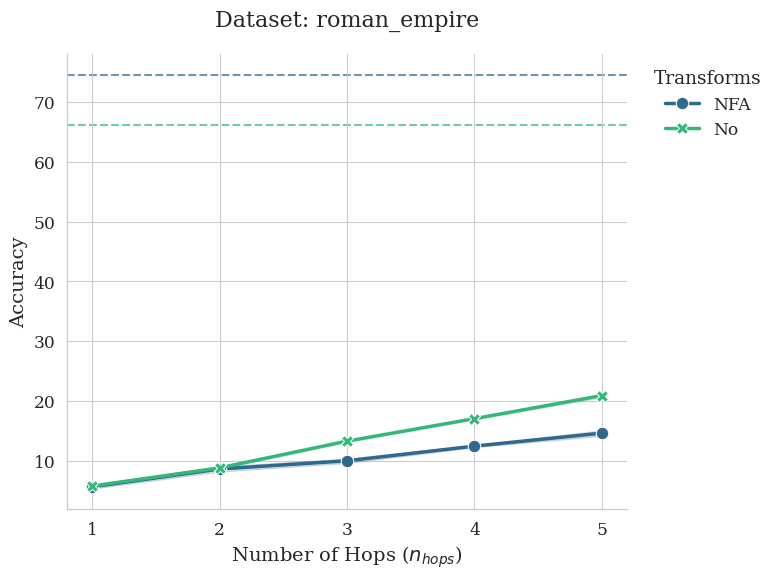

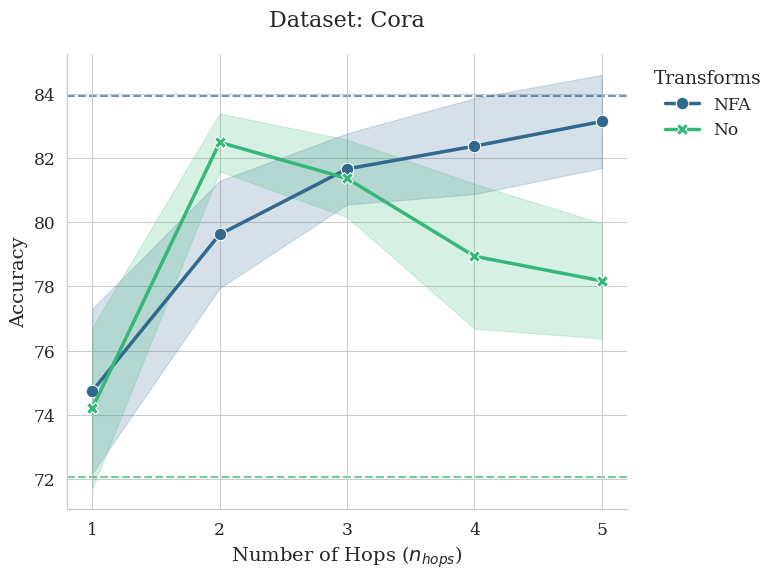

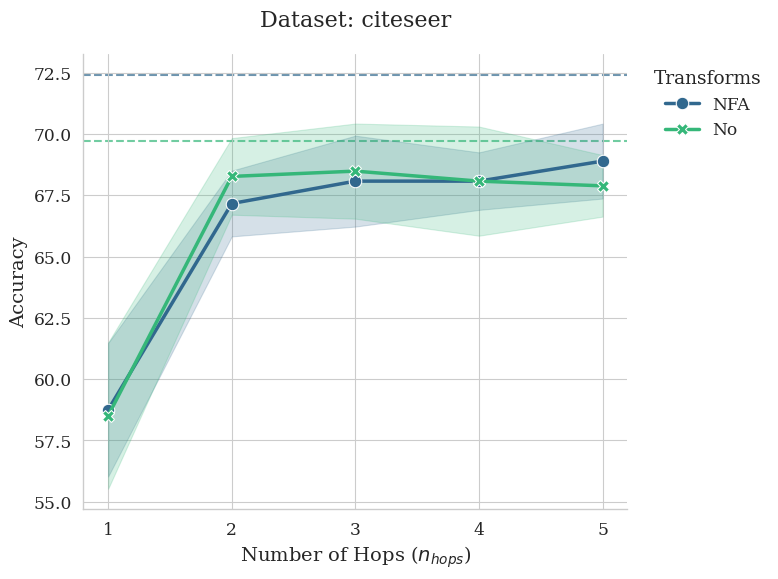

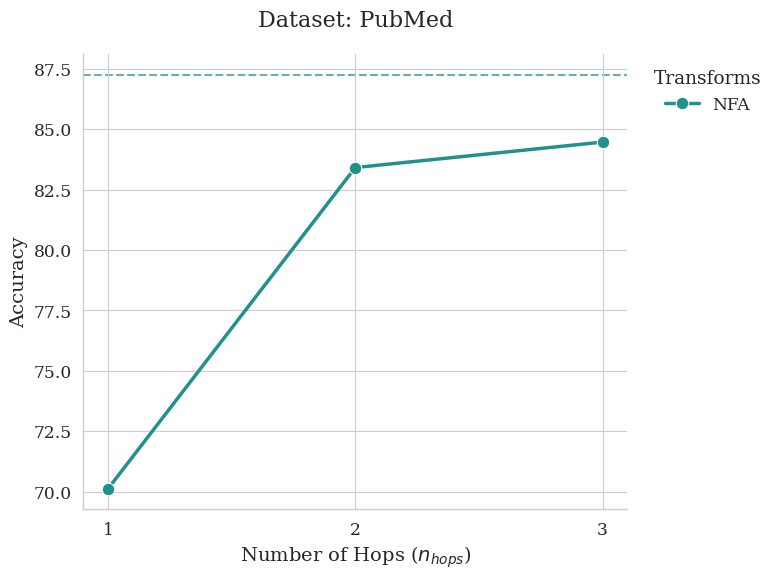

In [55]:
create_plot_specific_baselines(
    df_full=df_classification, 
    x_col='n_hops', 
    y_col='Accuracy', 
    hue_col='Transforms', 
    filter_col='NumTestNodes', 
    filter_val=1, 
    x_label=r'Number of Hops ($n_{hops}$)'
)

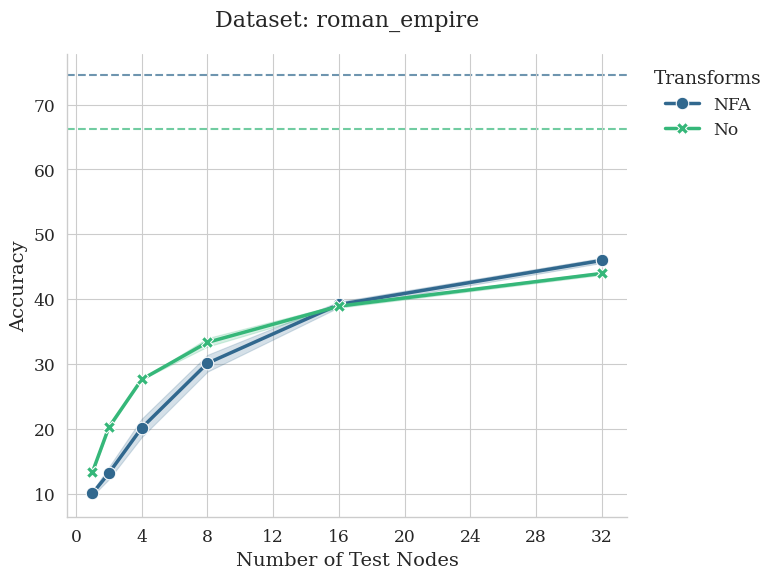

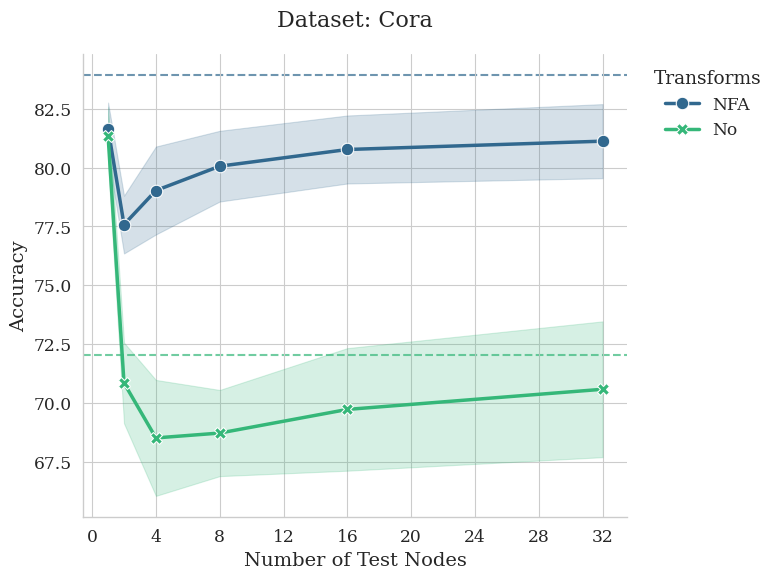

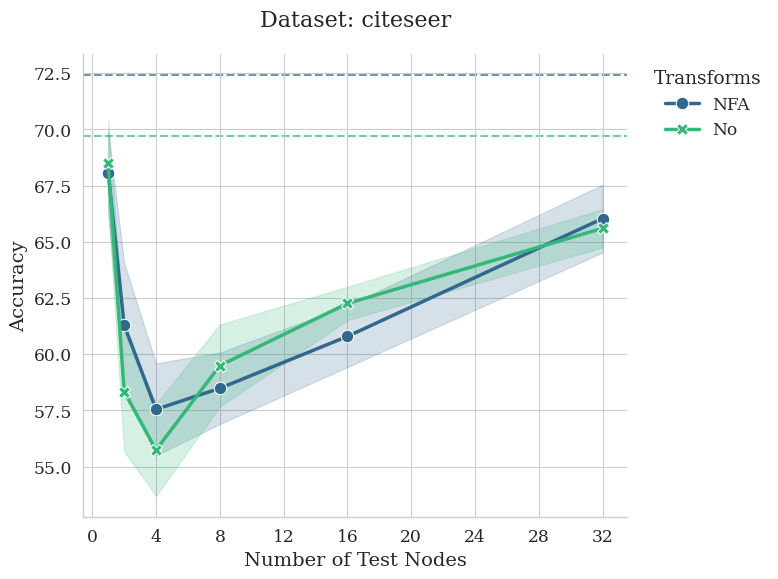

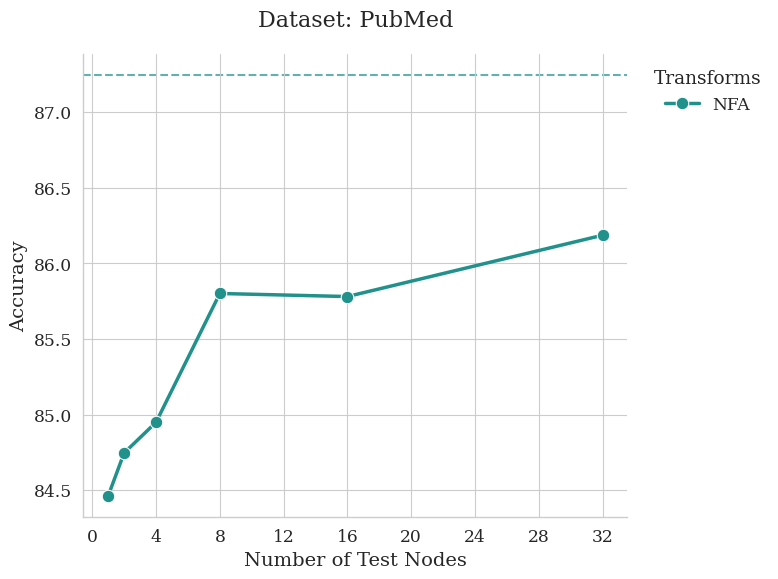

In [57]:
create_plot_specific_baselines(
    df_full=df_classification, 
    x_col='NumTestNodes',
    y_col='Accuracy',
    hue_col='Transforms',
    filter_col='n_hops',
    filter_val=3,
    x_label=r'Number of Test Nodes'
)

In [57]:
(
    df_classification.query(" Sampler == 'GraphHopSampler' ").groupby(
        ["Dataset", "Embedddings", "Backbone"]
    ).agg(Accuracy=("Accuracy", mean_pm_std))
    .sort_index()
    .reset_index()
    .pivot(
        columns = ["Dataset"],
        index = ["Backbone", "Embedddings"],
        values=["Accuracy"]
    )
)

Accuracy                            
Dataset                        Cora        PubMed      citeseer
Backbone Embedddings                                           
TabPFNC  True         71.63 ± 10.90  79.71 ± 7.31  59.31 ± 8.13

In [21]:
(
    df_classification.query(" Sampler == 'GraphHopSampler' ").groupby(
        ["Dataset", "Embedddings", "Backbone"]
    ).agg(AP=("AP", mean_pm_std))
    .sort_index()
    .reset_index()
    .pivot(
        columns = ["Dataset"],
        index = ["Backbone", "Embedddings"],
        values=["AP"]
    )
)

AP                                           \
Dataset                        Cora         PubMed amazon_ratings artnet-exp   
Backbone Embedddings                                                           
DTC      True                   NaN            NaN            NaN        NaN   
HGBC     True                   NaN            NaN            NaN        NaN   
LGBMC    True                   NaN            NaN            NaN        NaN   
LogR     True                   NaN            NaN            NaN        NaN   
MPLC     True                   NaN            NaN            NaN        NaN   
RFC      True                   NaN            NaN            NaN        NaN   
TabPFNC  True         0.884 ± 0.015  0.893 ± 0.003      nan ± nan  nan ± nan   

                                                                   \
Dataset                    citeseer    minesweeper      questions   
Backbone Embedddings                                                
DTC      True                   NaN  0.506 ± 0.004  0.505 ± 0.001   
HGBC     True                   NaN  0.505 ± 0.005            NaN   
LGBMC    True                   NaN  0.505 ± 0.005            NaN   
LogR     True                   NaN  0.508 ± 0.003            NaN   
MPLC     True                   NaN  0.510 ± 0.003            NaN   
RFC      True                   NaN  0.510 ± 0.003            NaN   
TabPFNC  True         0.642 ± 0.016  0.509 ± 0.005            NaN   

                                                    
Dataset                    tolokers     tolokers-2  
Backbone Embedddings                                
DTC      True         0.557 ± 0.003  0.547 ± 0.005  
HGBC     True         0.661 ± 0.012  0.699 ± 0.006  
LGBMC    True         0.658 ± 0.010  0.698 ± 0.009  
LogR     True         0.646 ± 0.008  0.643 ± 0.002  
MPLC     True         0.659 ± 0.010  0.646 ± 0.007  
RFC      True         0.631 ± 0.010  0.681 ± 0.010  
TabPFNC  True         0.675 ± 0.010  0.714 ± 0.011

In [22]:
(
    df_regression.query(" Sampler == 'GraphHopSampler' ").groupby(
        ["Dataset", "Embedddings", "Backbone"]
    ).agg(R2=("R2", mean_pm_std))
    .sort_index()
    .reset_index()
    .pivot(
        columns = ["Dataset"],
        index = ["Backbone", "Embedddings"],
        values=["R2"]
    )
)

R2                                \
Dataset                BachelorRate      BirthRate      DeathRate   
Backbone Embedddings                                                
TabPFNR  True         0.557 ± 0.043  0.249 ± 0.020  0.418 ± 0.021   

                                                                   \
Dataset                    Election   MedianIncome      MigraRate   
Backbone Embedddings                                                
TabPFNR  True         0.663 ± 0.019  0.694 ± 0.031  0.171 ± 0.068   

                                                      
Dataset              UnemploymentRate   city-roads-M  
Backbone Embedddings                                  
TabPFNR  True           0.761 ± 0.025  0.669 ± 0.008

# Binary Classification

## Full Graph Training

In [24]:
(
    df_classification.query(" Sampler == 'FullGraph' ").groupby(
        ["Dataset", "Transforms", "Backbone"]
    ).agg(AP=("AP", mean_pm_std))
    .sort_index()
    .reset_index()
    .pivot( 
        columns = ["Dataset"],
        index = ["Transforms", "Backbone"],
        values=["AP"]
    )
)[ [ ("AP", dataset) for dataset in binary_datasets_classification]]

AP                                         \
Dataset                 tolokers   tolokers-2  minesweeper    questions   
Transforms Backbone                                                       
NFA        DTC       0.57 ± 0.01  0.57 ± 0.00  0.59 ± 0.00  0.51 ± 0.00   
           HGBC      0.76 ± 0.01  0.77 ± 0.01  0.81 ± 0.01  0.61 ± 0.01   
           LGBMC     0.75 ± 0.01  0.78 ± 0.01  0.81 ± 0.01  0.61 ± 0.01   
           LogR      0.68 ± 0.01  0.65 ± 0.01  0.82 ± 0.01  0.59 ± 0.01   
           MPLC      0.72 ± 0.01  0.68 ± 0.02  0.84 ± 0.01  0.58 ± 0.01   
           RFC       0.75 ± 0.01  0.77 ± 0.01  0.80 ± 0.01  0.58 ± 0.01   
           TabPFNC   0.76 ± 0.00  0.78 ± 0.01  0.84 ± 0.01  0.58 ± 0.01   
No         DTC       0.56 ± 0.01  0.54 ± 0.00  0.50 ± 0.01  0.51 ± 0.00   
           HGBC      0.66 ± 0.00  0.70 ± 0.01  0.50 ± 0.01  0.59 ± 0.01   
           LGBMC     0.66 ± 0.00  0.70 ± 0.01  0.50 ± 0.01  0.59 ± 0.01   
           LogR      0.64 ± 0.01  0.64 ± 0.01  0.50 ± 0.01  0.58 ± 0.01   
           MPLC      0.65 ± 0.00  0.63 ± 0.03  0.50 ± 0.01  0.57 ± 0.01   
           RFC       0.63 ± 0.00  0.68 ± 0.01  0.50 ± 0.01  0.58 ± 0.01   
           TabPFNC   0.67 ± 0.00  0.72 ± 0.01  0.50 ± 0.01  0.59 ± 0.01   

                                                            
Dataset                web-fraud   artnet-exp city-reviews  
Transforms Backbone                                         
NFA        DTC               NaN  0.54 ± 0.00          NaN  
           HGBC              NaN  0.73 ± 0.01  0.89 ± 0.00  
           LGBMC             NaN  0.73 ± 0.00  0.89 ± 0.00  
           LogR              NaN  0.53 ± 0.01  0.72 ± 0.01  
           MPLC              NaN  0.54 ± 0.02  0.81 ± 0.07  
           RFC               NaN  0.70 ± 0.00  0.88 ± 0.00  
           TabPFNC           NaN  0.73 ± 0.01          NaN  
No         DTC       0.50 ± 0.00  0.53 ± 0.00  0.64 ± 0.01  
           HGBC      0.51 ± 0.00  0.71 ± 0.01  0.87 ± 0.00  
           LGBMC     0.51 ± 0.00  0.71 ± 0.01  0.87 ± 0.00  
           LogR              NaN  0.52 ± 0.01  0.72 ± 0.01  
           MPLC              NaN  0.59 ± 0.02  0.79 ± 0.03  
           RFC       0.51 ± 0.00  0.69 ± 0.01  0.86 ± 0.00  
           TabPFNC           NaN  0.71 ± 0.01          NaN

In [25]:
(
    df_classification.query(" Sampler == 'FullGraph' ").groupby(
        ["Dataset", "Transforms", "Backbone"]
    ).agg(AP=("AP", mean_pm_std))
    .sort_index()
    .reset_index()
    .pivot( 
        columns = ["Dataset"],
        index = ["Transforms", "Backbone"],
        values=["AP"]
    )
)[ [ ("AP", dataset) for dataset in binary_datasets_classification]].to_latex(float_format="%.2f")

'\\begin{tabular}{lllllllll}\n\\toprule\n &  & \\multicolumn{7}{r}{AP} \\\\\n & Dataset & tolokers & tolokers-2 & minesweeper & questions & web-fraud & artnet-exp & city-reviews \\\\\nTransforms & Backbone &  &  &  &  &  &  &  \\\\\n\\midrule\n\\multirow[t]{7}{*}{NFA} & DTC & 0.57 ± 0.01 & 0.57 ± 0.00 & 0.59 ± 0.00 & 0.51 ± 0.00 & NaN & 0.54 ± 0.00 & NaN \\\\\n & HGBC & 0.76 ± 0.01 & 0.77 ± 0.01 & 0.81 ± 0.01 & 0.61 ± 0.01 & NaN & 0.73 ± 0.01 & 0.89 ± 0.00 \\\\\n & LGBMC & 0.75 ± 0.01 & 0.78 ± 0.01 & 0.81 ± 0.01 & 0.61 ± 0.01 & NaN & 0.73 ± 0.00 & 0.89 ± 0.00 \\\\\n & LogR & 0.68 ± 0.01 & 0.65 ± 0.01 & 0.82 ± 0.01 & 0.59 ± 0.01 & NaN & 0.53 ± 0.01 & 0.72 ± 0.01 \\\\\n & MPLC & 0.72 ± 0.01 & 0.68 ± 0.02 & 0.84 ± 0.01 & 0.58 ± 0.01 & NaN & 0.54 ± 0.02 & 0.81 ± 0.07 \\\\\n & RFC & 0.75 ± 0.01 & 0.77 ± 0.01 & 0.80 ± 0.01 & 0.58 ± 0.01 & NaN & 0.70 ± 0.00 & 0.88 ± 0.00 \\\\\n & TabPFNC & 0.76 ± 0.00 & 0.78 ± 0.01 & 0.84 ± 0.01 & 0.58 ± 0.01 & NaN & 0.73 ± 0.01 & NaN \\\\\n\\cline{1-9}\n\\mu

# Multiclass datasets

## Full Graph

In [58]:
(
    df_classification.query(" Sampler == 'FullGraph' ").groupby(
        ["Dataset", "Transforms", "Backbone"]
    ).agg(Accuracy=("Accuracy", mean_pm_std))
    .sort_index()
    .reset_index()
    .pivot(
        columns = ["Dataset"],
        index = ["Transforms", "Backbone"],
        values=["Accuracy"]
    )
)[[ ("Accuracy", dataset) for dataset in multiclass_datasets_classification_homo]]

Accuracy                                  \
Dataset              amazon_ratings            Cora        citeseer   
Transforms Backbone                                                   
NFA        DTC       43.080 ± 0.262  69.158 ± 1.493  54.832 ± 1.229   
           HGBC      51.857 ± 0.615  83.043 ± 1.161  72.212 ± 1.593   
           LGBMC     52.967 ± 0.600  83.131 ± 1.484  72.260 ± 1.238   
           LogR      43.348 ± 0.336  85.702 ± 1.237  72.452 ± 1.413   
           MPLC      50.570 ± 0.560  85.081 ± 1.468  70.721 ± 1.421   
           RFC       54.026 ± 0.331  77.666 ± 0.720  69.279 ± 1.007   
           TabPFNC   41.058 ± 0.354  83.102 ± 1.362  71.659 ± 0.989   
No         DTC       39.739 ± 0.575  43.368 ± 1.323  49.832 ± 1.303   
           HGBC      46.513 ± 0.474  66.588 ± 1.766  67.212 ± 0.694   
           LGBMC     47.666 ± 0.395  66.972 ± 1.902  67.260 ± 1.162   
           LogR      38.818 ± 0.553  72.230 ± 0.911  65.962 ± 1.024   
           MPLC      45.063 ± 0.390  69.365 ± 2.078  65.481 ± 0.809   
           RFC       47.937 ± 0.756  56.869 ± 1.167  65.264 ± 0.676   
           TabPFNC   38.896 ± 0.192  70.133 ± 2.028  69.183 ± 0.777   

                                                     
Dataset                      PubMed         wiki_cs  
Transforms Backbone                                  
NFA        DTC       78.032 ± 0.683  66.617 ± 1.002  
           HGBC      88.284 ± 0.365  82.761 ± 0.320  
           LGBMC     88.183 ± 0.408  82.399 ± 0.468  
           LogR      87.270 ± 0.378  83.199 ± 0.188  
           MPLC      85.813 ± 0.523  82.358 ± 0.782  
           RFC       83.874 ± 0.380  79.385 ± 0.603  
           TabPFNC   87.245 ± 0.483  80.752 ± 0.679  
No         DTC       71.858 ± 0.894  50.984 ± 0.652  
           HGBC      85.079 ± 0.567  75.988 ± 0.390  
           LGBMC     84.892 ± 0.517  76.152 ± 0.353  
           LogR      84.564 ± 0.798  78.059 ± 0.607  
           MPLC      86.016 ± 0.215  77.833 ± 0.371  
           RFC       82.458 ± 0.462  69.624 ± 0.196  
           TabPFNC   85.781 ± 0.397  77.758 ± 0.375

In [28]:
(
    df_classification.query(" Sampler == 'FullGraph' ").groupby(
        ["Dataset", "Transforms", "Backbone"]
    ).agg(Accuracy=("Accuracy", mean_pm_std))
    .sort_index()
    .reset_index()
    .pivot(
        columns = ["Dataset"],
        index = ["Transforms", "Backbone"],
        values=["Accuracy"]
    )
)[[ ("Accuracy", dataset) for dataset in multiclass_datasets_classification]]

Accuracy                                            \
Dataset             amazon_ratings  roman_empire      citeseer          Cora   
Transforms Backbone                                                            
NFA        DTC        43.08 ± 0.26  57.74 ± 0.55  54.83 ± 1.23  69.16 ± 1.49   
           HGBC       51.86 ± 0.61  74.97 ± 0.51  72.21 ± 1.59  83.04 ± 1.16   
           LGBMC      52.97 ± 0.60  76.39 ± 0.33  72.26 ± 1.24  83.13 ± 1.48   
           LogR       43.35 ± 0.34  74.29 ± 0.31  72.45 ± 1.41  85.70 ± 1.24   
           MPLC       50.57 ± 0.56  71.94 ± 0.46  70.72 ± 1.42  85.08 ± 1.47   
           RFC        54.03 ± 0.33  69.29 ± 0.86  69.28 ± 1.01  77.67 ± 0.72   
           TabPFNC    41.06 ± 0.35           NaN  71.66 ± 0.99  83.10 ± 1.36   
No         DTC        39.74 ± 0.58  60.61 ± 0.51  49.83 ± 1.30  43.37 ± 1.32   
           HGBC       46.51 ± 0.47  63.64 ± 0.27  67.21 ± 0.69  66.59 ± 1.77   
           LGBMC      47.67 ± 0.39  63.67 ± 0.30  67.26 ± 1.16  66.97 ± 1.90   
           LogR       38.82 ± 0.55  64.47 ± 0.43  65.96 ± 1.02  72.23 ± 0.91   
           MPLC       45.06 ± 0.39  64.12 ± 0.40  65.48 ± 0.81  69.36 ± 2.08   
           RFC        47.94 ± 0.76  63.09 ± 0.34  65.26 ± 0.68  56.87 ± 1.17   
           TabPFNC    38.90 ± 0.19           NaN  69.18 ± 0.78  70.13 ± 2.03   

                                                 
Dataset                    PubMed       wiki_cs  
Transforms Backbone                              
NFA        DTC       78.03 ± 0.68  66.62 ± 1.00  
           HGBC      88.28 ± 0.37  82.76 ± 0.32  
           LGBMC     88.18 ± 0.41  82.40 ± 0.47  
           LogR      87.27 ± 0.38  83.20 ± 0.19  
           MPLC      85.81 ± 0.52  82.36 ± 0.78  
           RFC       83.87 ± 0.38  79.38 ± 0.60  
           TabPFNC   87.25 ± 0.48  80.75 ± 0.68  
No         DTC       71.86 ± 0.89  50.98 ± 0.65  
           HGBC      85.08 ± 0.57  75.99 ± 0.39  
           LGBMC     84.89 ± 0.52  76.15 ± 0.35  
           LogR      84.56 ± 0.80  78.06 ± 0.61  
           MPLC      86.02 ± 0.21  77.83 ± 0.37  
           RFC       82.46 ± 0.46  69.62 ± 0.20  
           TabPFNC   85.78 ± 0.40  77.76 ± 0.38

In [29]:
(
    df_classification.query(" Sampler == 'FullGraph' ").groupby(
        ["Dataset", "Transforms", "Backbone"]
    ).agg(Accuracy=("Accuracy", mean_pm_std))
    .sort_index()
    .reset_index()
    .pivot(
        columns = ["Dataset"],
        index = ["Transforms", "Backbone"],
        values=["Accuracy"]
    )
)[[ ("Accuracy", dataset) for dataset in multiclass_datasets_classification]].to_latex()

'\\begin{tabular}{llllllll}\n\\toprule\n &  & \\multicolumn{6}{r}{Accuracy} \\\\\n & Dataset & amazon_ratings & roman_empire & citeseer & Cora & PubMed & wiki_cs \\\\\nTransforms & Backbone &  &  &  &  &  &  \\\\\n\\midrule\n\\multirow[t]{7}{*}{NFA} & DTC & 43.08 ± 0.26 & 57.74 ± 0.55 & 54.83 ± 1.23 & 69.16 ± 1.49 & 78.03 ± 0.68 & 66.62 ± 1.00 \\\\\n & HGBC & 51.86 ± 0.61 & 74.97 ± 0.51 & 72.21 ± 1.59 & 83.04 ± 1.16 & 88.28 ± 0.37 & 82.76 ± 0.32 \\\\\n & LGBMC & 52.97 ± 0.60 & 76.39 ± 0.33 & 72.26 ± 1.24 & 83.13 ± 1.48 & 88.18 ± 0.41 & 82.40 ± 0.47 \\\\\n & LogR & 43.35 ± 0.34 & 74.29 ± 0.31 & 72.45 ± 1.41 & 85.70 ± 1.24 & 87.27 ± 0.38 & 83.20 ± 0.19 \\\\\n & MPLC & 50.57 ± 0.56 & 71.94 ± 0.46 & 70.72 ± 1.42 & 85.08 ± 1.47 & 85.81 ± 0.52 & 82.36 ± 0.78 \\\\\n & RFC & 54.03 ± 0.33 & 69.29 ± 0.86 & 69.28 ± 1.01 & 77.67 ± 0.72 & 83.87 ± 0.38 & 79.38 ± 0.60 \\\\\n & TabPFNC & 41.06 ± 0.35 & NaN & 71.66 ± 0.99 & 83.10 ± 1.36 & 87.25 ± 0.48 & 80.75 ± 0.68 \\\\\n\\cline{1-8}\n\\multirow[t]{7}

# Regression Datasets

## Full Graph 

### Topobench datasets

In [ ]:
(
    df_regression.query(" Sampler == 'FullGraph' ").groupby(
        ["Dataset", "Embedddings", "Backbone"]
    ).agg(MSE=("MSE", mean_pm_std))
    .sort_index()
    .reset_index()
    .pivot(
        columns = ["Dataset"],
        index = ["Backbone", "Embedddings"],
        values=["MSE"]
    )
)[ [ ("MSE", dataset) for dataset in topobench_regression]]

In [27]:
(
    df_regression.query(" Sampler == 'FullGraph' ").groupby(
        ["Dataset", "Embedddings", "Backbone"]
    ).agg(R2=("R2", mean_pm_std))
    .sort_index()
    .reset_index()
    .pivot(
        columns = ["Dataset"],
        index = ["Backbone", "Embedddings"],
        values=["R2"]
    )
)[ [ ("R2", dataset) for dataset in topobench_regression]]

R2                                  \
Dataset                BachelorRate       BirthRate       DeathRate   
Backbone Embedddings                                                  
DTR      True         0.330 ± 0.071  -0.623 ± 0.267  -0.062 ± 0.074   
HGBR     True         0.626 ± 0.043   0.132 ± 0.036   0.406 ± 0.032   
LGBMR    True         0.633 ± 0.040   0.130 ± 0.044   0.403 ± 0.035   
LinR     True         0.574 ± 0.037   0.117 ± 0.025   0.388 ± 0.023   
MLPR     True         0.653 ± 0.045   0.168 ± 0.038   0.464 ± 0.029   
RFR      True         0.638 ± 0.050   0.170 ± 0.026   0.446 ± 0.025   
TabPFNR  True         0.673 ± 0.048   0.219 ± 0.029   0.479 ± 0.029   
XGBR     True         0.596 ± 0.040   0.100 ± 0.028   0.364 ± 0.025   

                                                                     \
Dataset                     Election   MedianIncome       MigraRate   
Backbone Embedddings                                                  
DTR      True         -0.197 ± 0.054  0.243 ± 0.099  -0.828 ± 0.238   
HGBR     True          0.344 ± 0.041  0.574 ± 0.009   0.090 ± 0.059   
LGBMR    True          0.348 ± 0.039  0.577 ± 0.016   0.088 ± 0.064   
LinR     True          0.297 ± 0.033  0.543 ± 0.033   0.124 ± 0.039   
MLPR     True          0.400 ± 0.028  0.622 ± 0.027   0.148 ± 0.068   
RFR      True          0.380 ± 0.032  0.612 ± 0.020   0.108 ± 0.083   
TabPFNR  True          0.442 ± 0.031  0.654 ± 0.021   0.192 ± 0.047   
XGBR     True          0.300 ± 0.037  0.563 ± 0.031   0.001 ± 0.087   

                                       
Dataset              UnemploymentRate  
Backbone Embedddings                   
DTR      True           0.024 ± 0.126  
HGBR     True           0.502 ± 0.068  
LGBMR    True           0.505 ± 0.064  
LinR     True           0.305 ± 0.035  
MLPR     True           0.413 ± 0.039  
RFR      True           0.512 ± 0.055  
TabPFNR  True           0.538 ± 0.063  
XGBR     True           0.474 ± 0.051

### Graphland Datasets

In [28]:
(
    df_regression.query(" Sampler == 'FullGraph' ").groupby(
        ["Dataset", "Embedddings", "Backbone"]
    ).agg(MSE=("MSE", mean_pm_std))
    .sort_index()
    .reset_index()
    .pivot(
        columns = ["Dataset"],
        index = ["Backbone", "Embedddings"],
        values=["MSE"]
    )
)[[ ("MSE", dataset) for dataset in graphland_regression]]

KeyError: "[('MSE', 'web-traffic')] not in index"

In [ ]:
(
    df_regression.query(" Sampler == 'FullGraph' ").query(' Dataset in @graphland_regression').groupby(
        ["Dataset", "Embedddings", "Backbone"]
    ).agg(R2=("R2", mean_pm_std))
    .sort_index()
    .reset_index()
    .pivot(
        columns = ["Dataset"],
        index = ["Backbone", "Embedddings"],
        values=["R2"]
    )
).to_latex()

'\\begin{tabular}{lllllll}\n\\toprule\n &  & \\multicolumn{5}{r}{R2} \\\\\n & Dataset & artnet-views & avazu-ctr & city-roads-L & city-roads-M & hm-prices \\\\\nBackbone & Embedddings &  &  &  &  &  \\\\\n\\midrule\nDTR & True & -0.372 ± 0.018 & -0.532 ± 0.013 & 0.230 ± 0.021 & 0.381 ± 0.009 & 0.346 ± 0.011 \\\\\n\\cline{1-7}\nHGBR & True & 0.355 ± 0.002 & 0.262 ± 0.008 & 0.521 ± 0.007 & 0.633 ± 0.004 & 0.678 ± 0.007 \\\\\n\\cline{1-7}\nLGBMR & True & 0.357 ± 0.002 & 0.266 ± 0.006 & 0.522 ± 0.007 & 0.635 ± 0.005 & 0.682 ± 0.007 \\\\\n\\cline{1-7}\nLinR & True & 0.097 ± 0.005 & 0.195 ± 0.003 & 0.255 ± 0.005 & 0.375 ± 0.011 & 0.211 ± 0.003 \\\\\n\\cline{1-7}\nMLPR & True & 0.155 ± 0.007 & 0.203 ± 0.013 & 0.416 ± 0.015 & 0.452 ± 0.059 & -1.329 ± 0.948 \\\\\n\\cline{1-7}\nRFR & True & 0.335 ± 0.004 & 0.239 ± 0.004 & 0.570 ± 0.010 & 0.649 ± 0.005 & 0.675 ± 0.005 \\\\\n\\cline{1-7}\nTabPFNR & True & nan ± nan & 0.209 ± 0.002 & NaN & 0.661 ± 0.007 & 0.714 ± 0.007 \\\\\n\\cline{1-7}\nXGBR & Tr